In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
# load data
ir_df = pd.read_csv("../data/oc_2022_november/indreg_2018_2020_megye.csv", sep=";")
mne_df = pd.read_csv("../data/oc_2022_november/mne_share_nace3d_megye.csv", sep=";")
coa_df = pd.read_csv("../data/oc_2023_january/oc_m01_data_output_megye.csv", sep=";")

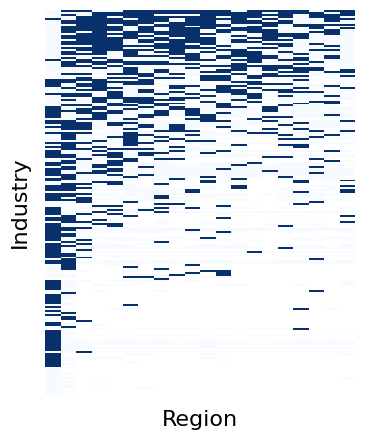

In [11]:
def mcp_matrix(df, key_cols, heatmap, fontsize, ax=None):
    table = df[key_cols]
    table.loc[table["rca18"] >=1, ["rca18"]] = 1
    table.loc[table["rca18"] < 1, ["rca18"]] = 0
    
    table = pd.pivot_table(table,
        values="rca18",
        index=["ind"],
        columns=["reg"],
        aggfunc=np.sum,
        margins=True,
        margins_name='total')
        
    table = table\
        .sort_values(by=["total"], ascending=False, axis=0)\
        .sort_values(by=["total"], ascending=False, axis=1)

    table = table.drop(["total"], axis=1).drop(["total"], axis=0)

    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap="Blues", ax=ax)
        ax.set_xlabel("Region", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        ax.set_xticklabels("")
        ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)
        
fig, ax = plt.subplots(1,1, figsize=(4,5))
mcp_matrix(ir_df, key_cols=["reg", "ind", "rca18"], fontsize=16, heatmap=True)

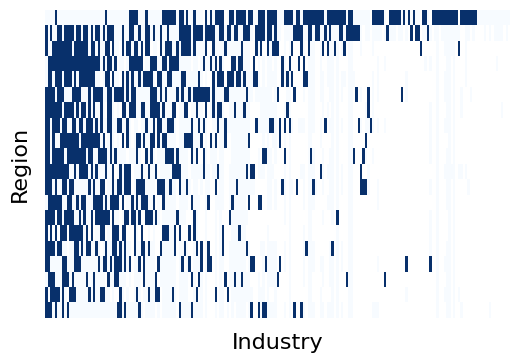

In [15]:
def t_mcp_matrix(df, key_cols, heatmap, fontsize, ax=None):
    table = df[key_cols]
    table.loc[table["rca18"] >=1, ["rca18"]] = 1
    table.loc[table["rca18"] < 1, ["rca18"]] = 0
    
    table = pd.pivot_table(table,
        values="rca18",
        index=["reg"],
        columns=["ind"],
        aggfunc=np.sum,
        margins=True,
        margins_name='total')
        
    table = table\
        .sort_values(by=["total"], ascending=False, axis=0)\
        .sort_values(by=["total"], ascending=False, axis=1)

    table = table.drop(["total"], axis=1).drop(["total"], axis=0)

    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap="Blues", ax=ax)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Region", size=fontsize)
        ax.set_xticklabels("")
        ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)
        
fig, ax = plt.subplots(1,1, figsize=(6,4))
t_mcp_matrix(ir_df, key_cols=["reg", "ind", "rca18"], fontsize=16, heatmap=True)

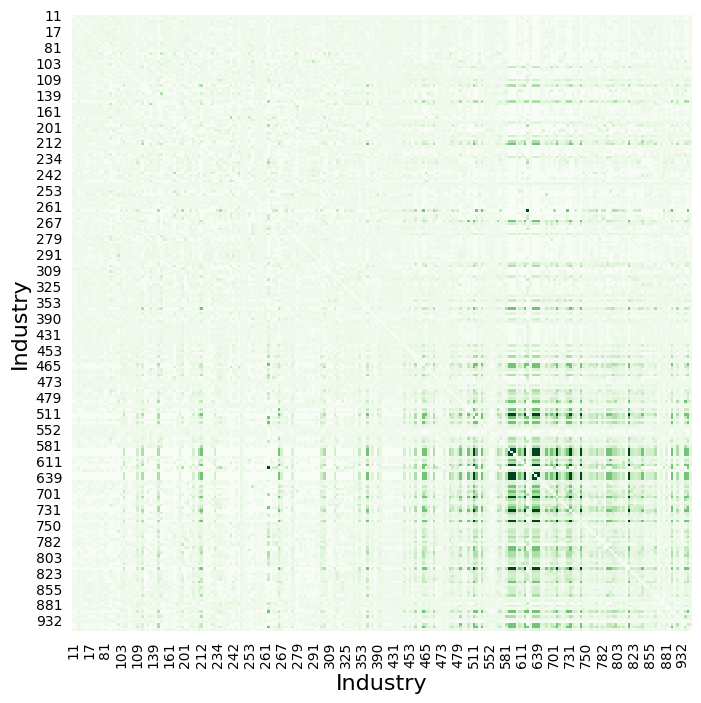

In [53]:
def mpp_matrix(df, key_cols, heatmap, fontsize, cmap, ax=None):
    table = df[key_cols]
    
    table = pd.pivot_table(table,
        values=key_cols[2],
        index=key_cols[0],
        columns=key_cols[1],
        aggfunc=np.mean,
        margins=True,
        margins_name='total')

    table = table.drop(["total"], axis=1).drop(["total"], axis=0)
    
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap=cmap, ax=ax)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        #ax.set_xticklabels("")
        #ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)
  
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(coa_df, key_cols=["ind1", "ind2", "coagg"], heatmap=True, fontsize=16, cmap="Greens", ax=None)


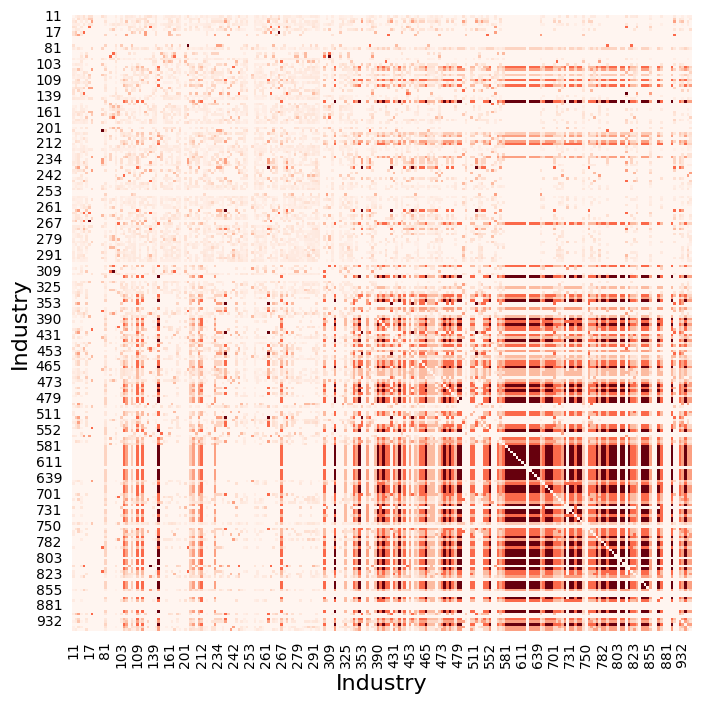

In [56]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(coa_df, key_cols=["ind1", "ind2", "coagg_mne"], heatmap=True, fontsize=16, cmap="Reds", ax=None)

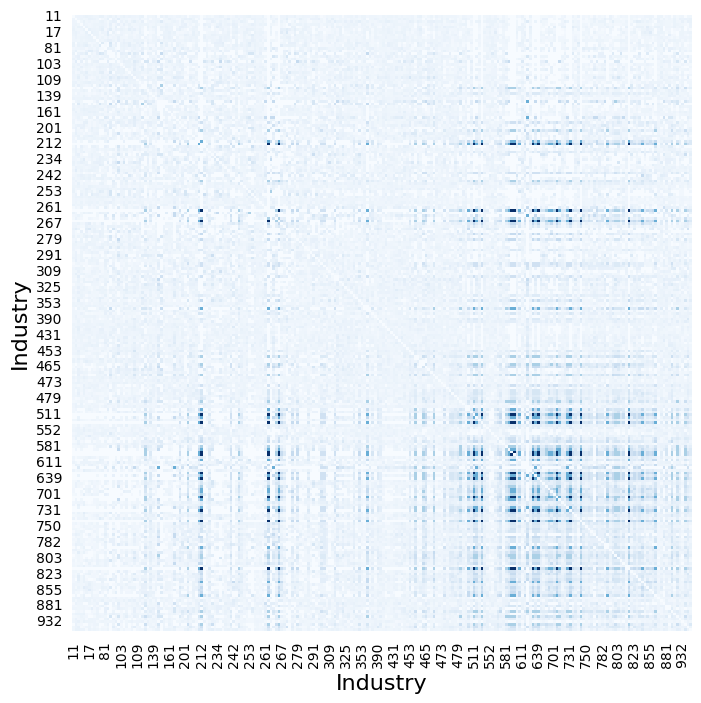

In [57]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(coa_df, key_cols=["ind1", "ind2", "coagg_local"], heatmap=True, fontsize=16, cmap="Blues", ax=None)

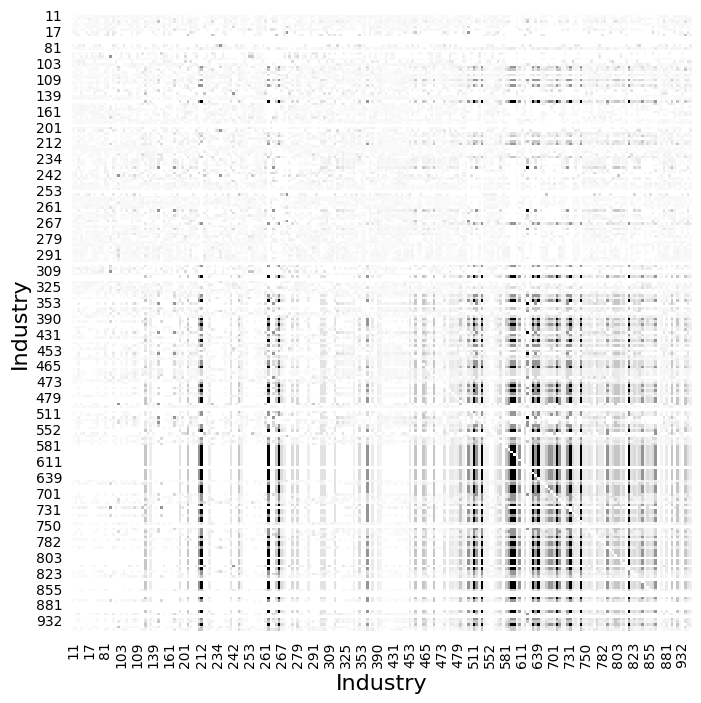

In [62]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(coa_df, key_cols=["ind1", "ind2", "coagg_mne_local"], heatmap=True, fontsize=16, cmap="Greys", ax=None)